## 9-7. 행렬 분해를 이용한 잠재 요인 협업 필터링 실습
이번에는 행렬 분해를 이용한 잠재 요인 협업 필터링을 직접 구현해 보겠습니다. 행렬 분해 잠재 요인 
협업 필터링은 SVD나 NMF 등을 적용할 수 있는데, 일반적으로 행렬 분해에는 SVD가 자주 사용되지 
만 사용자-아이템 평점 행렬에는 사용자가 평점을 매기지 않은 널 데이터가 많기 때문에 주로 SGD나 
ALS 기반의 행렬 분해를 이용한다고 말했습니다. 여기서는 SGD 기반의 행렬 분해를 구현하고 이를 기 
반으로 사용자에게 영화를 추천해 보겠습니다.
앞의 4절 잠재 요인 협업 필터링 절의 확률적 경사 하강법을 이용한 행렬 분해에서 사용한 예제 코드 
를 여기서 다시 활용합니다(본 절을 학습하기 전에 4절을 시간을 가지고 다시 한번 복습할 것을 권장 
합니다). 단, 이번에는 행렬 분해 로직 부분을 함수로 만들겠습니다. 새로운 주피터 노트북을 생성하 
고 확률적 경사 하강법을 이용한 행렬 분해 예제의 get_rmse() 함수를 그대로 사용하고 행렬 분해 로 
직을 새로운 matrix_factorization( ) 함수로 정리합니다. matrix_factorization(R, K, steps=200, 
learning_rate=0.01, r lambda = 0.01)에서 R은 원본 사용지一아이템 평점 행렬이며, K는 잠재 요인 
의 차원 수, steps는 SGD 의 반복 횟수, learningjrate는 학습률, rjambda는 L2 규제 계수입니다.


In [1]:
import numpy as np

def get_rmse(R, P, Q, non_zeros):
    error = 0
    for i, j, r in non_zeros:
        pred = np.dot(P[i, :], Q[j, :].T)
        error += pow(r - pred, 2)
    rmse = np.sqrt(error / len(non_zeros))
    return rmse

In [2]:
def matrix_factorization(R, K, steps=200, learning_rate=0.01, r_lambda = 0.01 ):
    num_users, num_items = R.shape
    # P와 Q 매트릭스의 크기를 지정하고 정규 분포를 가진 랜덤한 값으로 입력합니다.
    np.random.seed(1)
    P = np.random.normal(scale=1./K, size=(num_users, K))
    Q = np.random.normal(scale=1./K, size=(num_items, K))
    # R〉0 인 행 위치, 열 위치, 값을 non.zeros 리스트 객체에 저장.
    non_zeros = [ (i, j, R[i, j]) for i in range(num_users) for j in range(num_items) if R[i, j] >0 ]
    
    # SGD기법으로 우와 Q 매트릭스를 계속 업데이트.
    for step in range(steps):
        for i, j, r in non_zeros:
            # 실제 값과 예측 값의 차이인 오류 값 구함
            eij = r - np.dot(P[i, :], Q[j,:].T)
            # Regularization을 반영한 SGD 업데이트 공식 적용
            P[i, :] = P[i, :] + learning_rate*(eij * Q[j, :] - r_lambda*P[i, :]) 
            Q[j, :] = Q[j, :] + learning_rate*(eij * P[i, :] - r_lambda*Q[j, :])
        
        rmse = get_rmse(R, P, Q, non_zeros)
        if (step % 10) == 0 :
            print("### iteration step : ", step, " rmse : ", rmse)
    return P, Q

먼저 영화 평점 행렬 데이터를 새롭게 DataFrame으로 로딩한 뒤에 다시 사용자-아이템 평점 행렬로 
만들겠습니다.

In [3]:
pip install --upgrade numpy pandas

Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
import numpy as np
movies = pd.read_csv("C:/Users/User/OneDrive/바탕 화면/movies.csv")
ratings = pd.read_csv("C:/Users/User/OneDrive/바탕 화면/ratings.csv")
ratings = ratings[['userId', 'movieId', 'rating']]
ratings_matrix = ratings.pivot_table('rating', index='userId', columns='movieId')

# title 칼럼을 얻기 위해 movies와 조인 수행
rating_movies = pd.merge(ratings, movies, on='movieId')

# columns='title' 로 title 칼럼으로 pivot 수행.
ratings_matrix = rating_movies.pivot_table('rating', index='userId', columns='title')

다시 만들어진 사용자-아이템 평점 행렬을 matrix_factorization() 함수를 이용해 행렬 분해하겠습니 
다. 수행 시간이 오래 걸리므로 SGD 반복 횟수인 steps는 200회만 지정하겠습니다. 잠재 요인 차원 K 
는 50, 학습률과 L2 Regularization 계수는 모두 0.01 로 설정하고 수행합니다

In [5]:
P, Q = matrix_factorization(ratings_matrix.values, K=50, steps=200, learning_rate=0.01, r_lambda = 0.01) 
pred_matrix = np.dot(P, Q.T)

### iteration step :  0  rmse :  2.9023619751337115
### iteration step :  10  rmse :  0.7335768591017939
### iteration step :  20  rmse :  0.5115539026853437
### iteration step :  30  rmse :  0.37261628282537723
### iteration step :  40  rmse :  0.29608182991810134
### iteration step :  50  rmse :  0.252035319234162
### iteration step :  60  rmse :  0.22487503275269882
### iteration step :  70  rmse :  0.2068545530233151
### iteration step :  80  rmse :  0.19413418783028688
### iteration step :  90  rmse :  0.18470082002720317
### iteration step :  100  rmse :  0.1774292752720908
### iteration step :  110  rmse :  0.1716522696470752
### iteration step :  120  rmse :  0.1669518194687151
### iteration step :  130  rmse :  0.16305292191997445
### iteration step :  140  rmse :  0.15976691929679607
### iteration step :  150  rmse :  0.15695986999457326
### iteration step :  160  rmse :  0.1545339818671543
### iteration step :  170  rmse :  0.15241618551077693
### iteration step :  180  rmse

더 쉽게 영화 아이템 칼럼을 이해하기 위해 반환된 예측 사용자一아이템 평점 행렬을 영화 타이틀을 칼 
럼명으로 가지는 DataFrame으로 변경하겠습니다.

In [6]:
ratings_pred_matrix = pd.DataFrame(data=pred_matrix, index= ratings_matrix.index, columns = ratings_matrix.columns)
ratings_pred_matrix.head(3)

title,'71 (2014),'Hellboy': The Seeds of Creation (2004),'Round Midnight (1986),'Salem's Lot (2004),'Til There Was You (1997),'Tis the Season for Love (2015),"'burbs, The (1989)",'night Mother (1986),(500) Days of Summer (2009),*batteries not included (1987),...,Zulu (2013),[REC] (2007),[REC]² (2009),[REC]³ 3 Génesis (2012),anohana: The Flower We Saw That Day - The Movie (2013),eXistenZ (1999),xXx (2002),xXx: State of the Union (2005),¡Three Amigos! (1986),À nous la liberté (Freedom for Us) (1931)
userId,,,,,,,,,,,,,,,,,,,,,
1,3.055084,4.092018,3.564130,4.502167,3.981215,1.271694,3.603274,2.333266,5.091749,3.972454,...,1.402608,4.208382,3.705957,2.720514,2.787331,3.475076,3.253458,2.161087,4.010495,0.859474
2,3.170119,3.657992,3.308707,4.166521,4.311890,1.275469,4.237972,1.900366,3.392859,3.647421,...,0.973811,3.528264,3.361532,2.672535,2.404456,4.232789,2.911602,1.634576,4.135735,0.725684
3,2.307073,1.658853,1.443538,2.208859,2.229486,0.780760,1.997043,0.924908,2.970700,2.551446,...,0.520354,1.709494,2.281596,1.782833,1.635173,1.323276,2.887580,1.042618,2.293890,0.396941


이제 이렇게 만들어진 예측 사용자一아이템 평점 행렬 정보를 이용해 개인화된 영화 추천을 해 보겠 
습니다. 9.6절의 아이템 기반 최근접 이웃 협업 필터링 실습과 동일한 사용자 아이디 9번에 대한 영 
화 추천을 이번에는 잠재 요인 협업 필터링으로 추천해 보겠습니다. 9.6절에서 만든 get_unseen_ 
movies() 함수와 recomm_movie_by_userid() 함수를 다시 이용해 추천 영화를 추출합니다.

In [7]:
# 사용자 9번 영화추천
def get_unseen_movies(ratings_matrix, userId):
    # userId로 입력받은 사용자의 모든 영화 정보를 추출해 Series로 반환함.
    # 반환된 user_rating은 영화명(title)을 인덱스를 가지는 Series 객체임.
    user_rating = ratings_matrix.loc[userId, :]

    #user_rating이 0보다 크면 기존에 관람한 영화임. 대상 인덱스를 추출해 list 객체로 만듦.
    already_seen = user_rating[ user_rating > 0].index.tolist()

    # 모든 영화명을 list 객체로 만듦.
    movies_list = ratings_matrix.columns.tolist()

    # list comporehension으로 already_seen에 해당하는 영화는 movies_list에서 제외함.
    unseen_list = [ movie for movie in movies_list if movie not in already_seen]
    return unseen_list

def recomm_movie_by_userid(pred_df, userId, unseen_list, top_n = 10):

    # 예측 평점 DataFrame에서 사용자id 인덱스와 unseen_list로 들어온 영화명 칼럼을 추출해
    # 가장 예측 평점이 높은 순으로 정렬함.
    recomm_movies = pred_df.loc[userId, unseen_list].sort_values(ascending=False)[:top_n]

    return recomm_movies

In [8]:
# 사용자가 관람하지 않은 영화명 추출
unseen_list = get_unseen_movies(ratings_matrix, 9)

# 잠재 요인 협업 필터링으로 영화 추천
recomm_movies = recomm_movie_by_userid(ratings_pred_matrix, 9, unseen_list, top_n=10)

# 평점 데이터를 DataFrame으로 생성.
recomm_movies = pd.DataFrame(data=recomm_movies.values, index=recomm_movies.index, columns=['pred_score'])
recomm_movies

,pred_score
title,
Rear Window (1954),5.704612
"South Park: Bigger, Longer and Uncut (1999)",5.451100
Rounders (1998),5.298393
Blade Runner (1982),5.244951
Roger & Me (1989),5.191962
Gattaca (1997),5.183179
Ben-Hur (1959),5.130463
Rosencrantz and Guildenstern Are Dead (1990),5.087375
"Big Lebowski, The (1998)",5.038690


앞 절의 아이템 기반 협업 필터링 결과와는 추천된 영화가 많이 다릅니다. 특히 알프레드 히치콕 감독 
의 스릴러 영화인 ‘이창(Rear Window, 1954)’이 추천됐습니다. 그 뒤를 이어 어른을 위한 애니메이션 
영화인 ‘사우스파크(South Park： Bigger, Longer & Uncut)’가 두 번째로, 그리고 맷 데이먼이 주연한 
도박 영화 ‘라운더스(Rounders)’, 그 뒤를 이어 ‘블레이드 러너(Blade Runner)’, ‘로저와 나(Roger & 
Me)’, ‘가타카(Gattaca)’와 같이 훌륭한 영화지만 약간 어둡고 무거운 주제의 영화가 추천됐습니다.

## 9-8. 파이썬 추천 시스템 패키지-Surprise
### Surprise 패키지 소개
지금까지 콘텐츠 기반 필터링, 아이템 기반 협업 필터링, 그리고 잠재 요인 기반 협업 필터링을 파이썬 
코드로 구현해 봤습니다. 앞에서 다룬 예제 코드는 최적화나 수행 속도 측면에서 좀 더 보완이 필요합 
니다. 추천 시스템은 상업적으로 가치가 크기 때문에 별도의 패키지로 제공되면 매우 활용도가 높을 것 
입니다. 이번에는 파이썬 기반의 추천 시스템 구축을 위한 전용 패키지 중의 하나인 Surprise를 소개하 
겠습니다(아쉽게도 사이킷런은 추천 전용 모듈을 제공하지 않습니다). Surprise는 파이썬 기반에서 사 
이킷런과 유사한 API와 프레임워크를 제공합니다. 따라서 추천 시스템의 전반적인 알고리즘을 이해하 
고 사이킷런 사용 경험이 있으면 쉽게 사용할 수 있습니다.
Surprise는 conda 나 pip를 통해 설치합니다. Anaconda Prompt OS 창이나 OS 창을 엽니다(win- 
dows 10의 경우 Prompt OS 창을 ‘관리자 권한으로 실행’ 메뉴를 통해 열어야 합니다)

Surprise 패키지는 API를 이용해 쉽게 추천 시스템을 구축할 수 있게 만들어졌습니다. 주요 장점은 다 
음과 같습니다.
- 다양한 추천 알고리즘, 예를 들어 사용자 또는 아이템 기반 최근접 이웃 협업 필터링, SVD, SVD++, NMF 기반의 잠재 요인 협업 필터링을 쉽게 적용해 추천 시스템을 구축할 수 있습니다.
- Surprise의 핵심 API는 사이킷런의 핵심 API와 유사한 API명으로 작성됐습니다. 예를 들어 fit( ), predict( ) AP로 추천 데이터 학습과 예측, train_test_split( )으로 추천 학습 데이터 세트와 예측 데이터 세트 분리, cross_validate( ), GridSearchCV 클래스를 통해 추천 시스템을 위한 모델 셀렉션, 평가, 하이퍼 파라미터 튜닝 등의 기능을 제공합니다

### Surprise를 이용한 추천 시스템 구축
간단한 예제를 통해 Surprise 패키지의 개략적인 사용법을 익혀보겠습니다. 예제는 추천 데이터를 학 
습용과 테스트용 데이터 세트로 분리한 뒤 SVD 행렬 분해를 통한 잠재 요인 협업 필터링을 수행합니 
다. 먼저 새로운 주피터 노트북을 생성하고 Surprise의 관련 모듈을 임포트합니다.

In [6]:
import sys
import numpy
print(sys.version)
print(numpy.__file__)

3.11.15 | packaged by Anaconda, Inc. | (main, Mar 11 2026, 17:12:15) [MSC v.1942 64 bit (AMD64)]
c:\Users\User\anaconda3\envs\ml_env\Lib\site-packages\numpy\__init__.py


In [7]:
# 1. 꼬여있는 두 패키지 모두 삭제
!pip uninstall numpy scikit-surprise -y

# 2. 넘파이를 가장 안정적인 버전(1.26.4)으로 먼저 설치
!pip install numpy==1.26.4

# 3. 그 다음 surprise를 다시 설치
!pip install scikit-surprise

Found existing installation: numpy 2.4.3
Uninstalling numpy-2.4.3:
  Successfully uninstalled numpy-2.4.3
Found existing installation: scikit-surprise 1.1.4
Uninstalling scikit-surprise-1.1.4:
  Successfully uninstalled scikit-surprise-1.1.4
   ---------------------------------------- 0.0/15.8 MB ? eta -:--:--
   ----- ---------------------------------- 2.4/15.8 MB 11.2 MB/s eta 0:00:02
   ----------- ---------------------------- 4.7/15.8 MB 11.4 MB/s eta 0:00:01
   ----------------- ---------------------- 7.1/15.8 MB 11.8 MB/s eta 0:00:01
   ----------------------- ---------------- 9.4/15.8 MB 11.7 MB/s eta 0:00:01
   ------------------------------ --------- 12.1/15.8 MB 11.8 MB/s eta 0:00:01
   ------------------------------------ --- 14.4/15.8 MB 11.8 MB/s eta 0:00:01
   ---------------------------------------- 15.8/15.8 MB 11.4 MB/s  0:00:01
  Using cached scikit_surprise-1.1.4-cp311-cp311-win_amd64.whl


In [1]:
from surprise import SVD
from surprise import Dataset 
from surprise import accuracy 
from surprise.model_selection import train_test_split

추천을 위한 데이터 세트를 로딩해 보겠습니다. Surprise에서 데이터 로딩은 Dataset 클래스를 이용해서만 가능합니다. Surprise는 Movie Lens 데이터 세트의 사용자-영화 평점 데이터 포맷과 같이 userId(사용자 ID), movieId(영화 ID), rating(평점)과 같은 주요 데이터가 로우(Row) 레벨 형태로 돼 
있는 포맷의 데이터만 처리합니다.

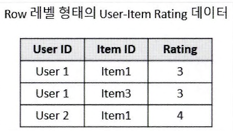

Surprise는 무비렌즈(MovieLens) 사이트에서 제공하는 과거 버전의 데이터 세트를 가져오는 API를 
제공합니다. Surprise Dataset 클래스의 load_builtin()은 무비렌즈 사이트에서 제공하는 과거 버전 
데이터 세트인 ‘ml-10*(10만 개 평점 데이터) 또는 ‘ml-lm’(100만 개 평점 데이터) 데이터를 아카 
이브 사이트로부터 내려받아 로컬 디렉터리에 저장한 뒤 데이터를 로딩합니다. 이렇게 로딩한 데이터 
세트를 Surprise 패키지의 train_test_split() API를 이용해 학습 데이터 세트와 테스트 데이터 세트로 
분리해 보겠습니다.

In [2]:
data = Dataset.load_builtin('ml-100k')
# 수행 시마다 동일하게 데이터를 분할하기 위해 random.state 값 부여
trainset, testset = train_test_split(data, test_size=.25, random_state=0)

Surprise에서 사용하는 ‘ml-100k’ 데이터 세트는 앞 예제에서 지금까지 사용한 movies.csv, ratings, 
csv 파일과는 차이가 있습니다. 무비렌즈 사이트에서 직접 내려받은 movies.csv, ratings.csv는 최근 
영화에 대한 평점 정보를 가지고 있지만, Surprise가 내려받은 ml-100k, ml-1m은 과거 버전의 데이 
터 세트입니다. 최신 데이터 세트인 ratings.csv의 경우 칼럼 분리 문자가 콤마(,)인 CSV 파일이지만, 
과거 버전의 데이터 파일은 분리 문자가 탭(\t) 문자입니다. Surprise에 사용자-아이템 평점 데이터를 적용할 때 주의해야 할 점은 무비렌즈 사이트에서 내려받은 데이터 파일과 동일하게 로우 레벨의 사용자-아이템 평점 데이터를 그대로 적용해야 한다는 것입니다. 앞에서 로우 레벨의 사용자-아이템 평점 데이터를 아이템 아이디를 칼럼명으로 변환한 형태의 사용자一아이템 평점 행렬 데이터로 변환했습니다. Surprise는 자체적으로 로우 레벨의 데이터를 칼럼 레벨의 데이터로 변경하므로 원본인 로우 레벨의 사용자-아이템 평점 데이터를 데이터 세트로 적용해야 합니다. 이제 SVD로 잠재 요인 협업 필터링을 수행하겠습니다. 적용하는 데이터 세트는 앞에서 소개한 train, test_split()으로 분리된 학습 데이터 세트입니다. 먼저 algo = SVD()와 같이 알고리즘 객체를 생성합니다. 이 알고리즘 객체에 fit(학습 데이터 세트)을 수행해 학습 데이터 세트 기반으로 추천 알고리즘을 학습합니다.

In [3]:
algo = SVD(random_state=0)
algo.fit(trainset)

학습된 추천 알고리즘을 기반으로 테스트 데이터 세트에 대해 추천을 수행하겠습니다. Surprise에서 
추천을 예측하는 메서드는 test()와 predict(), 두 개입니다. test()는 사용자-아이템 평점 데이터 세 
트 전체에 대해서 추천을 예측하는 메서드입니다. 즉, 입력된 데이터 세트에 대해 추천 데이터 세트를 
만들어 줍니다. predict()는 개별 사용자와 영화에 대한 추천 평점을 반환해 줍니다. 예제를 통해 차 
이를 확인해 보겠습니다. 먼저 test() 메서드부터 실행해 보겠습니다. 테스트 데이터 세트 전체에 대해 
추천 영화 평점 데이터를 생성한 뒤에 최초 5개만 추출하는 예제입니다

In [4]:
predictions = algo.test( testset )
print('prediction type :', type(predictions), ' size:',len(predictions)) 
print('prediction 결과의 최초 5개 추출') 
predictions[:5]

prediction type : <class 'list'>  size: 25000
prediction 결과의 최초 5개 추출


[Prediction(uid='120', iid='282', r_ui=4.0, est=3.5114147666251547, details={'was_impossible': False}),
 Prediction(uid='882', iid='291', r_ui=4.0, est=3.573872419581491, details={'was_impossible': False}),
 Prediction(uid='535', iid='507', r_ui=5.0, est=4.033583485472447, details={'was_impossible': False}),
 Prediction(uid='697', iid='244', r_ui=5.0, est=3.8463639495936905, details={'was_impossible': False}),
 Prediction(uid='751', iid='385', r_ui=4.0, est=3.1807542478219157, details={'was_impossible': False})]

SVD 알고리즘 객체의 test(데이터 세트) 메서드의 호출 결과는 파이썬 리스트이며 크기는 입력 인 
자 데이터 세트의 크기와 같은 25,000개입니다. 호출 결과로 반환된 리스트 객체는 25,000개의 
Prediction 객체를 내부에 가지고 있습니다. Prediction 객체는 Surprise 패키지에서 제공하는 데이 
터 타입이며, 개별 사용자 아이디(uid), 영화(또는 아이템) 아이디(iid)와 실제 평점(r_ui) 정보에 기반 
해 Surprise의 추천 예측 평점(est) 데이터를 튜플 형태로 가지고 있습니다. Prediction 객체의 details 
속성은 내부 처리 시 추천 예측을 할 수 없는 경우에 로그용으로 데이터를 남기는 데 사용됩니다. ‘was_impossible’이 True이면 예측값을 생성할 수 없는 데이터라는 의미입니다. 여기서는 모두 False 
입니다.리스트 객체 내에 내포된 Prediction 객체의 uid, iid, r_ui, est 등의 속성에 접근하려면 객체명.uid와 같은 형식으로 가능합니다. 다음은 3개의 Prediction 객체에서 uid, iid, est 속성을 추출한 예제입니다.

In [5]:
[ (pred.uid, pred.iid, pred.est) for pred in predictions[:3] ]

[('120', '282', 3.5114147666251547),
 ('882', '291', 3.573872419581491),
 ('535', '507', 4.033583485472447)]

이번에는 Surprise 패키지의 다른 추천 예측 메서드인 predict()를 이용해 추천 예측을 해보겠습니다. 
predict()는 개별 사용자의 아이템에 대한 추천 평점을 예측해 줍니다. 인자로 개별 사용자 아이디, 아 
이템 아이디를 입력하면 추천 예측 평점을 포함한 정보를 반환합니다(기존 평점 정보(r_ui)는 선택 사 
항이며 사용자 아이디, 아이템 아이디는 문자열로 입력해야 합니다)

In [6]:
# 사용자 아이디, 아이템 아이디는 문자열로 입력해야 함.
uid = str(196) 
iid = str(302) 
pred = algo.predict(uid, iid) 
print(pred)

user: 196        item: 302        r_ui = None   est = 4.49   {'was_impossible': False}


결과처럼 predict( )는 개별 사용자와 아이템 정보를 입력하면 추천 예측 평점을 est로 반환합니다. 
test() 메서드는 입력 데이터 세트의 모든 사용자와 아이템 아이디에 대해서 predict()를 반복적으로 
수행한 결과라고 생각하면 좀 더 이해하기 쉬울 것입니다. 테스트 데이터 세트를 이용해 추천 예측 평점과 실제 평점과의 차이를 평가해 보겠습니다. Surprise의 accuracy 모듈은 RMSE, MSE 등의 방법으로 추천 시스템의 성능 평가 정보를 제공합니다. accuracy 모듈의 rmse（）를 이용해 RMSE 평가 결과를 확인해 보겠습니다.

In [7]:
accuracy.rmse(predictions)

RMSE: 0.9467


0.9466860806937948

이처럼 Surprise 패키지를 이용하면 쉽게 추천 시스템을 구현할 수 있습니다. 이제는 내장 데이터 세 
트가 아닌 다른 데이터 파일을 로딩해 추천 시스템을 구현해 보겠습니다. 이전 절에서 사용한 ratings, 
csv와 movies.csv 파일을 이용할 것입니다. 그전에 먼저 Surprise 패키지를 구성하는 모듈에 대해서 
좀 더 살펴본 뒤에 구현을 진행하겠습니다

### Surprise 주요 모듈 소개
#### Dataset
앞에서도 말했듯이 Surprise는 userjd（사용자 아이디）, item_id（아이템 아이디）, rating（평점） 데이터가 로우 레벨로 된 데이터 세트만 적용할 수 있습니다. 데이터의 첫 번째 칼럼을 사용자 아이디, 두 번째 칼럼을 아이템 아이디, 세 번째 칼럼을 평점으로 가정해 데이터를 로딩하고 네 번째 칼럼부터는 
아예 로딩을 수행하지 않습니다. 예를 들어 userjd, itemjd, rating, time_stamp 필드로 구분된 데 이터라면 앞 3개 필드만 로딩하고 이후 time_stamp 필드는 로딩에서 제외됩니다. 무비렌즈 아카이브 
서버에서 자동으로 내려받는 데이터 파일뿐만 아니라 일반 데이터 파일이나 판다스 DataFrame에서도 
로딩할 수 있습니다. 단, 데이터 세트의 칼럼 순서가 사용자 아이디, 아이템 아이디, 평점 순으로 반드 
시 돼 있어야 합니다.

#### OS 파일 데이터를 Surprise 데이터 세트로 로딩
Dataset.load_from_file API를 이용해 지정된 디렉터리에 있는 사용자一아이템 평점 데이터를 로딩하 
겠습니다. 이제부터 사용할 데이터 파일은 이전 절에서 사용한 ratings.csv와 movies.csv입니다. 먼저 Surprise에 OS 파일을 로딩할 때의 주의할 점은 로딩되는 데이터 파일에 칼럼명을 가지는 헤더 문자열이 있어서는 안 된다는 것입니다. 여기서 사용할 ratings.csv 파일은 맨 처음 위치에 칼럼명을 헤더로 가지고 있습니다. 판다스 DataFrame의 to_csv( ) 함수를 이용해 간단하게 이 칼럼 헤더를 삭제하고 새로운 파일인 ratings_noh.csv로 저장하겠습니다.

In [8]:
import pandas as pd
ratings = pd.read_csv( "C:/Users/User/OneDrive/바탕 화면/ratings.csv")
# ratings_noh.csv 파일로 언로드 시 인덱스와 헤더를 모두 제거한 새로운 파일 생성.
ratings.to_csv("C:/Users/User/OneDrive/바탕 화면/ratings_noh.csv", index=False, header=False)

새롭게 생성된 ratings_noh.csv 파일은 ratings.csv 파일에서 헤더가 삭제된 파일입니다. 이제 
ratings_noh.csv를 DataSet 모듈의 load_from_file( )을 이용해 DataSet로 로드하겠습니다. 먼저 
Dataset.load_from_file()을 적용하기 전에 Reader 클래스를 이용해 데이터 파일의 파싱 포맷을 정
의해야 합니다. Reader 클래스는 로딩될 ratings_noh.csv 파일의 파싱 정보를 알려주기 위해 사용됩
니다. 지금 로딩하려는 ratings_noh.csv는 칼럼 헤더가 없고, 4개의 칼럼이 콤마로만 분리돼 있습니
다. 이 4개의 칼럼이 사용자 아이디, 아이템 아이디, 평점, 타임스탬프임을 로딩할 때 알려줘야 합니다. Reader 클래스의 생성자에 각 필드의 칼럼명과 칼럼 분리문자, 그리고 최소〜최대 평점을 입력해 객체 
를 생성하고, load_from_file()로 생성된 Reader 객체를 참조해 데이터 파일을 파싱하면서 로딩합 
니다.다음 예제에서는 Reader 객체 생성 시에 Iine_format 인자로 user, item, rating, timestamp의 4개 
의 칼럼으로 데이터가 구성돼 있음을 명시했고, 각 칼럼의 분리 문자는 콤마, 평점의 단위는 0.5, 최대 
평점은 5점으로 설정했습니다. 이렇게 Reader 설정이 완료되면 Dataset.load_from_file()은 이를 기 
반으로 데이터를 파싱하면서 Dataset를 로딩합니다. 로딩 시 ratings_noh.csv 파일에서 앞의 3개 칼 
럼만 로딩되고 timestamp 칼럼은 제외 됩니다.

In [9]:
from surprise import Reader
reader = Reader(line_format='user item rating timestamp', sep=',', rating_scale=(0.5, 5)) 
data=Dataset.load_from_file("C:/Users/User/OneDrive/바탕 화면/ratings_noh.csv", reader=reader)

Surprise 데이터 세트는 기본적으로 무비렌즈 데이터 형식을 따르므로 무비렌즈 데이터 형식이 아닌 
다른 OS 파일의 경우 Reader 클래스를 먼저 설정해야 합니다. Reader 클래스의 주요 생성 파라미터 
는 다음과 같습니다.
- line_format (string)： 칼럼을 순서대로 나열합니다. 입력된 문자열을 공백으로 분리해 칼럼으로 인식합니다.
- sep (char)： 칼럼을 분리하는 분리자이며, 디폴트는 V입니다. 판다스 DataFrame에서 입력받을 경우에는 기재할 필요가 없습니다.
- rating_scale (tuple, optional)： 평점 값의 최소 〜 최대 평점을 설정합니다. 디폴트는 (1, 5)이지만 ratings.csv 파일의 경우는 최소 평점이 0.5, 최대 평점이 5이므로 (0.5, 5)로 설정했습니다.

이제 SVD 행렬 분해 기법을 이용해 추천을 예측해 보겠습니다. 잠재 요인 크기 K 값을 나타내는 파라 
미터인 n_factors를 50으로 설정해 데이터를 학습한 뒤에 테스트 데이터 세트를 적용해 예측 평점을 
구하겠습니다. 그리고 예측 평점과 실제 평점 데이터를 RMSE로 평가하겠습니다.

In [10]:
trainset, testset = train_test_split(data, test_size=.25, random_state=0)

# 수행 시마다 동일한 결과를 도출하기 위해 random_state 설정
algo = SVD(n_factors=50, random_state=0)

# 학습 데이터 세트로 학습하고 나서 테스트 데이터 세트로 평점 예측 후 RMSE 평가 
algo.fit(trainset) 
predictions = algo.test( testset ) 
accuracy.rmse(predictions)

RMSE: 0.8682


0.8681952927143516

#### 판다스 DataFrame에서 Surprise 데이터 세트로 로딩
Dataset.load_from_df( )를 이용하면 판다스의 DataFrame에서도 Surprise 데이터 세트로 로딩할 
수 있습니다. 주의할 점은 DataFrame 역시 사용자 아이디, 아이템 아이디, 평점 칼럼 순서를 지켜야 
한다는 것입니다. ratings.csv 파일을 DataFrame으로 로딩한 ratings에서 Surprise 데이터 세트로 로 
딩하려면 Dataset.load_from_df(ratings[[,iiserld,, 'movield', 'rating']], reader)와 같이 파라미 
터를 입력하면 됩니다. 다음은 이를 이용한 SVD 추천 예측을 코드로 작성한 것입니다.

In [11]:
import pandas as pd
from surprise import Reader, Dataset

ratings = pd.read_csv("C:/Users/User/OneDrive/바탕 화면/ratings.csv")
reader = Reader(rating_scale=(0.5, 5.0))

# ratings DataFrame에서 칼럼은 사용자 아이디, 아이템 아이디, 평점 순서를 지켜야 합니다.
data = Dataset.load_from_df(ratings[['userId', 'movieId', 'rating']], reader) 
trainset, testset = train_test_split(data, test_size=.25, random_state=0)

algo = SVD(n_factors=50, random_state=0) 
algo.fit(trainset) 
predictions = algo.test( testset ) 
accuracy.rmse(predictions)

RMSE: 0.8682


0.8681952927143516

### Surprise 추천 알고리즘 클래스
Surprise에서 추천 예측을 위해 자주 사용되는 추천 알고리즘 클래스는 다음과 같습니다.
- SVD: 행렬 분해를 통한 잠재 요인 협업 필터링을 위한 SVD 알고리즘
- KNNBasic: 최근접 이웃 협업 필터링을 위한 KNN 알고리즘
- BaselineOnly: 사용자 Bias와 아이템 Bias를 감안한 SGD 베이스라인 알고리즘

이 밖에도 SVD++, NMF 등 다양한 유형의 알고리즘을 수행할 수 있습니다. Surprise SVD의 비용 함수는 사용자 베이스라인(Baseline) 편향성을 감안한 평점 예측에 Regularization을 적용한 것입니다.

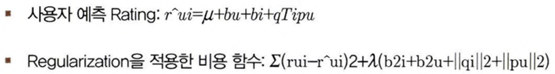

SVD 클래스의 입력 파라미터는 다음과 같습니다. 주로 n_factors와 n_epochs의 값을 변경해 튜닝할 
수 있으나 튜닝 효과는 크지 않습니다. biased의 경우는 큰 이슈가 없는 한 디폴트인 True로 설정을 유 
지하는 것이 좋습니다.

- n_factors: 잠재 요인 K의 개수. 디폴트는 100, 커질수록 정확도가 높아질 수 있으나 과적합 문제가 발생할 수 있습니다.
- n_epochs: SGD(Stochastic Gradient Descent) 수행 시 반복 횟수, 디폴트는 20
- biased (bool): 베이스라인 사용자 편향 적용 여부이며, 디폴트는 True

SVD++ 알고리즘의 RMSE, MAE 성적이 가장 좋지만, 상대적으로 시간이 너무 오래 걸려 데이터가 
조금만 더 커져도 사용하기가 어려울 것으로 보입니다. SVD++를 제외하면 SVD와 k-NN Baseline 
이 가장 성능 평가 수치가 좋습니다. k-NN 자체는 성능이 상대적으로 뒤지지만, Baseline을 결합한 
경우 성능 평가 수치가 대폭 향상됐습니다. Baseline이라는 의미는 각 개인이 평점을 부여하는 성향을 
반영해 평점을 계산하는 방식을 말합니다. 여기서 평점에 Baseline을 결합한 방식을 간략하게 설명하 겠습니다.

### 베이스라인 평점
영화나 상품의 평가도 각 개인의 성향에 따라 같은 아이템이더라도 평가가 달라질 수 있습니다. 싫은 소리를 별로 안 하는 사람의 경우는 전반적으로 평가에 후한 경향이 있습니다. 반면에 다른 이를 생각해서라도 냉정한 평가를 해야 한다고 생각하는 사람도 있을 것입니다. 이러한 개인의 성향을 반영해 아이템 평가에 편향성(bias) 요소를 반영하여 평점을 부과하는 것을 베이스라인 평점 (Baseline Rating) 이라고 힙니다. 보통 베이스라인 평점은 전체 평균 평점 + 사용자 편향 점수 + 아이템 편향 점수 공식으로 계산됩니다.
- 전체 평균 평점 = 모든 사용자의 아이템에 대한 평점을 평균한 값
- 사용자 편향 점수 = 사용자별 아이템 평점 평균 값 - 전체 평균 평점
- 아이템 편향 점수 = 아이템별 평점 평균 값 - 전체 평균 평점

영화 평점을 베이스라인 평점을 고려해 적용해 보겠습니다. 가령 모든 사용자의 평균적인 영화 평점이 3.5이고(전체 평균 평점: 3.5), ‘어벤저스 3편’을 모든 사용자가 평균적으로 평점 4.2로 평가했다면 영화 평가를 늘 깐깐하게 하는 사용자 A가 ‘어벤저스 3편’을 어떻게 평가할 것인지 예상해 보겠습니다.

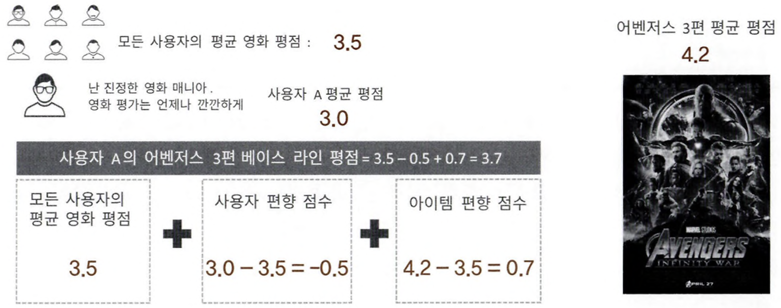

전체 영화의 평균 평점은 3.5이고 사용자 편향 점수는 사용자 A의 평균 영화 평점인 3.0 - 3.5(전체 
영화 평균 평점) = -0.5, 아이템 편향 점수는 ‘어벤저스 3’의 평균 평점 4.2 - 3.5(전체 평균 평점) = 
0.7로 계산할 수 있습니다. 따라서 사용자 A의 ‘어벤저스 3’의 베이스라인 평점은 3.5 - 0.5 + 0.7 = 
3.7 입니다.

### 교차 검증과 하이퍼파라미터 튜닝
Surprise는 교차 검증과 하이퍼 파라미터 튜닝을 위해 사이킷런과 유사한 cross_validate( )와 GridSearchCV 클래스를 제공합니다. 먼저 교차 검증을 위한 cross_validate() 함수의 사용법부터 살펴보겠습니다. 해당 함수는 surprise.model_sdection 모듈 내에 존재하며, 폴드된 데이터 세트의 개수와 성능 측정 방법을 명시해 교차 검증을 수행합니다. 다음 예제에서는 cross_validate()를 이용해 ratings.csv를 DataFrame으로 로딩한 데이터를 5개의 학습/검증 폴드 데이터 세트로 분리해 교차 검증을 수행하고 RMSE, MAE로 성능 평가를 진행합니다. cross_validate()의 인자로 알고리즘 객체, 데이터, 성능 평가 방법(measures), 폴드 데이터 세트 개수(cv)를 입력합니다.

In [12]:
from surprise.model_selection import cross_validate

# 판다스 DataFrame에서 Surprise 데이터 세트로 데이터 로딩
ratings = pd.read_csv("C:/Users/User/OneDrive/바탕 화면/ratings.csv") # reading data in pandas df
reader = Reader(rating_scale=(0.5, 5.0))
data = Dataset.load_from_df(ratings[['userId', 'movieId', 'rating']], reader)

algo = SVD(random_state=0)
cross_validate(algo, data, measures=[ 'RMSE', 'MAE'], cv=5, verbose=True)

Evaluating RMSE, MAE of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.8778  0.8751  0.8686  0.8636  0.8843  0.8739  0.0072  
MAE (testset)     0.6740  0.6729  0.6667  0.6659  0.6791  0.6717  0.0049  
Fit time          5.99    3.87    3.51    3.50    3.89    4.15    0.94    
Test time         0.49    0.48    0.55    0.32    0.90    0.55    0.19    


{'test_rmse': array([0.87779835, 0.87512437, 0.86862357, 0.86359045, 0.88429494]),
 'test_mae': array([0.67402639, 0.67292461, 0.66670336, 0.66594366, 0.67907998]),
 'fit_time': (5.994663953781128,
  3.867478370666504,
  3.5093555450439453,
  3.495680093765259,
  3.889219045639038),
 'test_time': (0.4945659637451172,
  0.4759693145751953,
  0.5495128631591797,
  0.3204779624938965,
  0.898296594619751)}

cross_validate()는 위의 출력 결과와 같이 폴드별 성능 평가 수치와 전체 폴드의 평균 성능 평가 수 
치를 함께 보여줍니다(교차 검증 세트의 분할 방식이 수행 시마다 달라져서 책의 출력 결과와 여러분이 
코드를 수행할 때의 출력 결과가 약간씩 다를 수 있습니다).Surprise의 GridSearchCV도 사이킷런의 GridSearchCV와 유사하게 교차 검증을 통한 하이퍼 파라미터 최적화를 수행합니다. 하이퍼 파라미터 최적화는 알고리즘 유형에 따라 다를 수 있지만, SVD의 경우 주로 점진적 하강 방식(Stochastic Gradient Descent)의 반복 횟수를 지정하는 n_epochs와 SVD의 잠재 요인 K의 크기를 지정하는 n_factors를 튜닝합니다. 'n_epochs'： [20, 40, 60], 'n_factors'： [50, 100, 200]로 변경하면서 CV가 3일 때의 최적 하이퍼 파라미터를 도출해 보겠습니다. 데이터는 앞 예제에서 사용한 ratings.csv를 DataFrame으로 로딩한 데이터를 그대로 사용합니다.

In [13]:
from surprise.model_selection import GridSearchCV

# 최적화할 파라미터를 딕셔너리 형태로 지정
param_grid = {'n_epochs':[20, 40, 60], 'n_factors': [50, 100, 200] }

# CV를 3개 폴드 세트로 지정, 성능 평가는 rmse, mse로 수행하도록 GridSearchCV 구성 
gs = GridSearchCV(SVD, param_grid, measures=['rmse', 'mae'], cv=3) 
gs.fit(data)

# 최고 RMSE Evaluation 점수와 그때의 하이퍼 파라미터 
print(gs.best_score['rmse']) 
print(gs.best_params['rmse'])

0.876340756247512
{'n_epochs': 20, 'n_factors': 50}


'n_epochs'： 20, 'njactors'： 50일 때 3개 폴드의 검증 데이터 세트에서 최적 RMSE가 약 0.8769로 
도출됐습니다.

### Surprise를 이용한 개인화 영화 추천 시스템 구축
Surprise를 이용해 잠재 요인 협 업 필터 링 기반의 개인화된 영화 추천을 구현해 보겠습니다. Surprise 
패키지는 간결하지만 기능을 조금 보강할 필요가 있습니다. 지금까지 살펴본 Surprise 예제는 학습 데 
이터로 fit()을 호출해 학습한 뒤 테스트 데이터로 test()를 호출해 예측 평점을 계산하고 MSE/RMSE 
로 성능을 평가했습니다. 이제는 Surprise 패키지로 학습된 추천 알고리즘을 기반으로 특정 사용자가 
아직 평점을 매기지 않은(관람하지 않은) 영화 중에서 개인 취향에 가장 적절한 영화를 추천해 보겠습 
니다. 이번 예제에서는 ratings.csv 데이터를 학습 데이터와 테스트 데이터로 분리하지 않고 전체를 학습 데이터로 사용합니다. 그런데 Surprise는 데이터 세트를 train_test_split()을 이용해 내부에서 사용하는 
TrainSet 클래스 객체로 변환하지 않으면 fit()을 통해 학습할 수가 없습니다. 따라서 데이터 세트를 그 
대로 fit()에 적용한 다음 코드는 오류를 일으킵니다

In [14]:
# 다음 코드는 train_test_split( )으로 분리되지 않는 데이터 세트에 fit( )을 호출해 오류가 발생합니다. 
data = Dataset.load_from_df(ratings[['userId', 'movieId', 'rating']], reader) 
algo = SVD(n_factors=50, random_state=0) 
algo.fit(data)

AttributeError: 'DatasetAutoFolds' object has no attribute 'n_users'

데이터 세트 전체를 학습 데이터로 사용하려면 DatasetAutoFolds 클래스를 이용하면 됩니다. DatasetAutoFolds 객체를 생성한 뒤에 build_full_trainset() 메서드를 호출하면 전체 데이터를 학습 데이터 세트로 만들 수 있습니다.

In [15]:
from surprise.dataset import DatasetAutoFolds

reader = Reader(line_format='user item rating timestamp', sep=',', rating_scale=(0.5, 5))
# DatasetAutoFolds 클래스를 ratings_noh.csv 파일 기반으로 생성.
data_folds = DatasetAutoFolds(ratings_file="C:/Users/User/OneDrive/바탕 화면/ratings_noh.csv", reader=reader)

# 전체 데이터를 학습 데이터로 생성함.
trainset = data_folds.build_full_trainset()

DatasetAutoFolds의 b나ild_full_trainset() 메서드를 이용해 생성된 학습 데이터를 기반으로 학습을 
수행하겠습니다. 그리고 이후에 특정 사용자에 영화를 추천하기 위해 아직 보지 않은 영화목록을 확인 
해 보겠습니다. 먼저 SVD를 이용해 학습을 수행합니다.

In [16]:
algo = SVD(n_epochs=20, n_factors=50, random_state=0) 
algo.fit(trainset)

특정 사용자는 userid = 9인 사용자로 지정하겠습니다. 간단하게 Surprise 패키지의 API를 이용해 예 
제를 수행하기 위해 userid 9가 아직 평점을 매기지 않은 영화를 movield 42로 선정한 뒤 예측 평점 
을 계산해 보겠습니다. 영화의 상세 정보는 movies.csv 파일에 있으므로 해당 파일을 DataFrame으로 로딩합니다.

In [17]:
# 영화에 대한 상세 속성 정보 DataFrame 로딩
movies = pd.read_csv("C:/Users/User/OneDrive/바탕 화면/movies.csv")
# userld=9의 movield 데이터를 추출해 movield=42 데이터가 있는지 확인.
movieIds = ratings[ratings['userId']==9] ['movieId']

if movieIds[movieIds==42].count() == 0:
    print('사용자 아이디 9는 영화 아이디 42의 평점 없음')
print(movies[movies['movieId']==42])

사용자 아이디 9는 영화 아이디 42의 평점 없음
    movieId                   title              genres
38       42  Dead Presidents (1995)  Action|Crime|Drama


이 movield 42인 영화에 대해서 userid 9 사용자의 추천 예상 평점은 predict() 메서드를 이용하면 
알 수 있습니다. 학습된 SVD 객체에서 predict() 메서드 내에 userId와 movield 값을 입력해주면 됩 
니다. 단, 이 값은 모두 문자열 값이어야 합니다

In [18]:
uid = str(9) 
iid = str(42)
pred = algo.predict(uid, iid, verbose=True)

user: 9          item: 42         r_ui = None   est = 3.13   {'was_impossible': False}


추천 예측 평점은 est 값으로 3.13입니다. 사용자가 평점을 매기지 않은 영화의 추천 예측 평점을 간단 
하게 구하는 방법을 알았으니 이제 사용자가 평점을 매기지 않은 전체 영화를 추출한 뒤에 예측 평점 
순으로 영화를 추천해 보겠습니다. 먼저 추천 대상이 되는 영화를 추출하겠습니다. Surprise 내부의 데 
이터 객체에 대한 액세스 제약 등으로 인해 앞 절에서 사용한 get_unseen_movies()는 사용하지 않 
고 새롭게 get_unseen_surprise() 함수를 만들고 이를 이용해 아이디 9인 사용자가 아직 평점을 매 
기지 않은 영화 정보를 반환합니다.

In [19]:
def get_unseen_surprise(ratings, movies, userId):
    # 입력값으로 들어온 userId에 해당하는 사용자가 평점을 매긴 모든 영화를 리스트로 생성 
    seen_movies = ratings[ratings['userId'] == userId]['movieId'].tolist()

    # 모든 영화의 movieId를 리스트로 생성.
    total_movies = movies['movieId' ].tolist()
    
    # 모든 영화의 movieId 중 이미 평점을 매긴 영화의 movield를 제외한 후 리스트로 생성 
    unseen_movies= [movie for movie in total_movies if movie not in seen_movies] 
    print('평점 매긴 영화 수:', len(seen_movies), '추천 대상 영화 수:', len(unseen_movies), '전체 영화 수:', len(total_movies))
    return unseen_movies

unseen_movies = get_unseen_surprise(ratings, movies, 9)

평점 매긴 영화 수: 46 추천 대상 영화 수: 9696 전체 영화 수: 9742


사용자 아이디 9번은 전체 9742개의 영화중에서 46개만 평점을 매겼습니다. 따라서 추천 대상 영화는 
9696개이며, 이 중 앞에서 학습된 추천 알고리즘 클래스인 SVD를 이용해 높은 예측 평점을 가진 순으 
로 영화를 추천해 보겠습니다. 이를 위해 recomm_movie_by_surprise() 함수를 새롭게 생성합니다. 이 함수는 인자로 학습이 완료된 추천 알고리즘 객체, 추천 대상 사용자 아이디, 추천 대상 영화의 리스 
트 객체, 그리고 추천 상위 N개 개수를 받습니다. recomm_movie_by_surprise()는 추천 대상 영화 모두를 대상으로 추천 알고리즘 객체의 predict() 메서드를 호출하고 그 결과인 Prediction 객체를 리스트 객체로 저장합니다. 그리고 이렇게 저장된 리스트 내부의 Prediction 객체를 예측 평점이 높은 순으로 다시 정렬한 뒤 Top—N개의 Prediction 객체에서 영화 아이디, 영화 제목, 예측 평점 정보를 추출해 반환합니다.

In [21]:
def recomm_movie_by_surprise(algo, userId, unseen_movies, top_n=10):
    # 알고리즘 객체의 predict() 메서드를 평점이 없는 영화에 반복 수행한 후 결과를 list 객체로 저장 
    predictions = [algo.predict(str(userId), str(movieId)) for movieId in unseen_movies]
    
    # predictions list 객체는 surprise의 Predictions 객체를 원소로 가지고 있음.
    # [Prediction(uid='9', iid='1', est=3.69), Prediction(uid='9', iid='2', est=2.98),,,,]
    
    # 이를 est 값으로 정렬하기 위해서 아래의 sortkey_est 함수를 정의함.
    # sortkey_est 함수는 list 객체의 sort() 함수의 키 값으로 사용되어 정렬 수행. 
    def sortkey_est(pred):
        return pred.est
    # sortkey_est( ) 반환값의 내림 차순으로 정렬 수행하고 top_n개의 최상위 값 추출.
    predictions.sort(key=sortkey_est, reverse=True)
    top_predictions= predictions[:top_n]
    
    # top_n으로 추출된 영화의 정보 추출. 영화 아이디, 추천 예상 평점, 제목 추출 
    top_movie_ids = [ int(pred.iid) for pred in top_predictions] 
    top_movie_rating = [ pred.est for pred in top_predictions] 
    top_movie_titles = movies[movies.movieId.isin(top_movie_ids)]['title']
    
    top_movie_preds = [ (id, title, rating) for id, title, rating in zip(top_movie_ids, top_movie_titles, top_movie_rating)]
    return top_movie_preds

unseen_movies = get_unseen_surprise(ratings, movies, 9)
top_movie_preds = recomm_movie_by_surprise(algo, 9, unseen_movies, top_n=10)

print('##### Top-10 추천 영화 리스트 #####')
for top_movie in top_movie_preds:
    print(top_movie[1], ":", top_movie[2])

평점 매긴 영화 수: 46 추천 대상 영화 수: 9696 전체 영화 수: 9742
##### Top-10 추천 영화 리스트 #####
Usual Suspects, The (1995) : 4.306302135700814
Star Wars: Episode IV - A New Hope (1977) : 4.281663842987387
Pulp Fiction (1994) : 4.278152632122759
Silence of the Lambs, The (1991) : 4.226073566460876
Godfather, The (1972) : 4.1918097904381995
Streetcar Named Desire, A (1951) : 4.154746591122658
Star Wars: Episode V - The Empire Strikes Back (1980) : 4.122016128534504
Star Wars: Episode VI - Return of the Jedi (1983) : 4.108009609093436
Goodfellas (1990) : 4.083464936588478
Glory (1989) : 4.07887165526957


9번 아이디 사용자에게는 케빈 스페이시 주연의 ‘유주얼 서스펙트(Usual Suspect)’, 그리고 ‘펄프픽션’, 
‘양들의 침묵’, ‘대부’와 '좋은 친구들’ 같은 서스펜스/스릴러/범죄 영화 및 스타워즈와 같은 액션 영화 등이 주로 추천됐습니다. 이처럼 Surprise 패키지는 복잡한 알고리즘을 직접 구현하지 않고도 쉽고 간결 
한 API를 이용해 파이썬 기반에서 추천 시스템을 구축할 수 있도록 해줍니다.

## 9-9. 정리
추천 시스템은 기업 애플리케이션에서 매우 중요한 위치를 차지하고 있습니다. 특히 온라인 스토어의 
경우 뛰어난 추천 시스템은 매출 향상으로 이어지는 많은 사례로 인하여 많은 기업들이 추천 시스템의 
예측 성능을 향상시키기 위해 알고리즘과 데이터 수집에 노력을 기울이고 있습니다.
이번 장에서는 추천 시스템의 대표적인 방식인 콘텐츠 기반 필터링과 협업 필터링을 살펴봤습니다. 콘 
텐츠 기반 필터링은 아이템（상품, 영화, 서비스 등）을 구성하는 여러 가지 콘텐츠 중 사용자가 좋아하 
는 콘텐츠를 필터링하여 이에 맞는 아이템을 추천하는 방식입니다. 예를 들어 영화 추천의 경우 사용자 
가 좋아하는 영화를 분석한 뒤, 이 영화의 콘텐츠와 유사한 다른 영화를 추천하는 것입니다. 영화의 경 
우 이러한 콘텐츠의 예는 장르, 감독, 영화배우, 영화 키워드와같은 요소들이 될 수 있습니다. 이들 요 
소들을 결합하여, 하나의 콘텐츠 특징으로 피처 벡터화한 뒤에 이들 피처 벡터와 가장 유사한 다른 피 
처 벡터를 가진 영화를 추천하는 것입니다.
협업 필터링은 최근접 이웃 협업 필터링과 잠재 요인 협업 필터링으로 나뉩니다. 최근접 이웃 협업 필 
터링은 다시 사용자 기반（사용자-사용자）과 아이템 기반（아이템-아이템）으로 나뉘며, 이중 아이템 기 
반이 더 많이 사용됩니다. 아이템 기반 최근접 이웃 방식은 특정 아이템과 가장 근접하게 유사한 다른 
아이템들을 추천하는 방식입니다. 이 유사도의 기준이 되는 것은 사용자들의 아이템에 대한 평가를 벡 
터화한 값입니다. 이를 위해 모든 아이템을 행으로. 모든 사용자를 열로, 그리고 사용자별-아이템 평 
점을 값으로 하는 아이템-사용자 행렬 데이터 세트를 만들고, 아이템별로 코사인 유사도를 이용해 사 
용자 평점 피처 벡터에 따른 Top-N 유사 아이템을 추천하는 예제를 구현해 봤습니다.
잠재 요인 협업 필터링은 많은 추천 시스템에서 활용하는 방식입니다. 사용자-아이템 평점 행렬 데이 
터에 숨어 있는 잠재 요인을 추출하여 사용자가 아직 평점을 매기지 않은 아이템에 대한 평점을 예측하 
여 이를 추천에 반영하는 방식입니다. 이렇게 잠재 요인을 추출하기 위해서 다차원의 사용자-아이템 
평점 행렬을 저차원의 사용자-잠재요인, 아이템-잠재요인 행렬로 분해하는데, 이러한 기법을 행렬 분 
해라고 합니다. 그리고 이러한 행렬 분해 기법을 경사 하강법으로 구현한 예제를 실습해 봤습니다.
마지막으로 파이썬의 추천 시스템 패키지 중 하나인 Surprise를 소개했습니다. Surprise는 사이킷런과 
유사한 API를 지향하며, 간단한 API만을 이용해 파이썬 기반에서 추천 시스템을 구현해 줍니다. 추천 
시스템이 가지는 엄청난 가치로 인해 많은 기업들이 이의 추천 예측 성능 향상을 위해 엄청난 노력을 
기울이고 있습니다. 이를 위해서는 추천 시스템의 기반 지식과 구현 로직에 대한 철저한 이해가 필수이 
기에 이 장에서 소개한 추천 시스템의 내용이 이를 위한 도움이 될 수 있었으면 하는 마음으로 이 장을 
마무리하겠습니다 